In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import RobustScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = RobustScaler()
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [19]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,-0.497635,1,0,1,0,0,1,0.0,0,-0.747766,0.0,0.600320,0.075008,0.231096
1,-0.473435,0,0,0,0,1,0,0.0,1,0.159774,0.0,-0.690705,-0.466877,-0.387041
2,-0.113739,0,1,0,0,0,1,0.0,1,0.610629,1.0,-0.308082,0.641923,0.210342
3,0.826312,0,0,0,0,1,0,0.0,1,0.494088,0.0,-0.987020,-0.399206,-0.398539
4,0.596634,0,0,0,0,1,0,0.0,1,1.007387,0.0,-0.641777,-0.293211,-0.315926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.000000,0,0,1,0,0,1,1.0,0,-0.747766,0.0,-0.109388,-0.294765,-0.236855
135,0.671213,0,0,1,0,0,1,1.0,0,-0.747766,1.0,-0.399297,1.027319,0.352293
136,-0.235838,0,0,1,0,0,1,1.0,1,0.560275,0.0,0.518153,-0.059989,0.075327
137,0.421516,0,0,1,0,0,1,1.0,1,1.620942,1.0,-0.353490,0.464201,0.118722


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

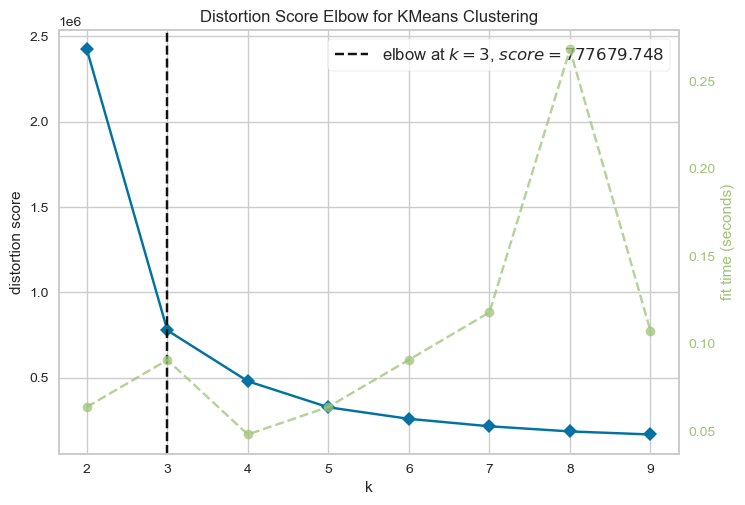

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [21]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['OS', 'event_OS']]], axis=1)
    coxph.fit(X_cluster, duration_col='OS', event_col='event_OS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 0: Most important feature: uicc8_III-IV, Coefficient: 1.107420167076039


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 1: Most important feature: MTV, Coefficient: 0.50470418381235


<lifelines.CoxPHFitter: fitted with 139 total observations, 82 right-censored observations>

Cluster 2: Most important feature: hpv_related, Coefficient: -1.3994025496184521


In [22]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [23]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = RobustScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [24]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [25]:
X_new

,uicc8_III-IV,MTV,hpv_related
0,0.0,7.934,0.0
1,0.0,1.656,0.0
2,1.0,14.502,0.0
3,0.0,2.440,0.0
4,0.0,3.668,0.0
...,...,...,...
134,0.0,3.650,1.0
135,1.0,18.967,1.0
136,0.0,6.370,1.0
137,1.0,12.443,1.0


In [26]:
X_new_std

,uicc8_III-IV,MTV,hpv_related
0,0.0,0.075008,0.0
1,0.0,-0.466877,0.0
2,1.0,0.641923,0.0
3,0.0,-0.399206,0.0
4,0.0,-0.293211,0.0
...,...,...,...
134,0.0,-0.294765,1.0
135,1.0,1.027319,1.0
136,0.0,-0.059989,1.0
137,1.0,0.464201,1.0


In [27]:
MAASTRO_new

,uicc8_III-IV,MTV,hpv_related
0,0,22.841,1
1,1,5.660,0
2,1,7.791,0
3,1,7.908,0
4,0,15.237,1
...,...,...,...
94,1,6.110,0
95,1,7.182,0
96,1,16.483,1
97,0,9.981,1


In [28]:
MAASTRO_new_std

,uicc8_III-IV,MTV,hpv_related
0,0,1.361702,1
1,1,-0.121272,0
2,1,0.062665,0
3,1,0.072763,0
4,0,0.705364,1
...,...,...,...
94,1,-0.082431,0
95,1,0.010099,0
96,1,0.812913,1
97,0,0.251694,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [29]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:39:12,611] A new study created in memory with name: no-name-d378d812-5f0b-44b6-a1dc-a310415cb3a6


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823


[I 2024-04-13 23:39:13,104] A new study created in memory with name: no-name-ba483f8a-8e39-495c-a584-4e56c0ce0650


Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:13,092] Trial 0 finished with value: 0.743776284197207 and parameters: {}. Best is trial 0 with value: 0.743776284197207.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.743776284197207], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 12, 678916), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 13, 91558), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.743776284197207


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17596691829963726
Fold 2 IBS: 0.20513786974221754
Fold 3 IBS: 0.16460093493027642
Fold 4 IBS: 0.1410071500761203
Fold 5 IBS: 0.24271027564677292
[I 2024-04-13 23:39:13,671] Trial 0 finished with value: 0.18588462973900488 and parameters: {}. Best is trial 0 with value: 0.18588462973900488.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18588462973900488], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 13, 192734), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 13, 671400), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18588462973900488


In [30]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [31]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.186


#### Test

In [32]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [33]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.666
IBS score: 0.222


In [34]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [35]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:39:13,953] A new study created in memory with name: no-name-ee95c1b1-6895-490f-aa56-e2e0169e2089


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.577922077922078
Fold 2 C-index: 0.7522321428571429
Fold 3 C-index: 0.7009803921568627
Fold 4 C-index: 0.8143459915611815
Fold 5 C-index: 0.6384976525821596
[I 2024-04-13 23:39:14,246] Trial 0 finished with value: 0.696795651415885 and parameters: {}. Best is trial 0 with value: 0.696795651415885.


[I 2024-04-13 23:39:14,264] A new study created in memory with name: no-name-7137f879-832e-49c8-a0e4-51abcc102435




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.696795651415885], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 14, 315), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 14, 246154), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.696795651415885


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2139765181546733
Fold 2 IBS: 0.22157791264663632
Fold 3 IBS: 0.2045359418172904
Fold 4 IBS: 0.22473803252862104
Fold 5 IBS: 0.21812431348528585
[I 2024-04-13 23:39:14,680] Trial 0 finished with value: 0.21659054372650138 and parameters: {}. Best is trial 0 with value: 0.21659054372650138.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054372650138], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 14, 299517), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 14, 680106), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054372650138


In [37]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [38]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.697
train_ibs:  0.217


#### Test

In [39]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [40]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.65


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [41]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [42]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:39:14,970] A new study created in memory with name: no-name-488cc3f2-b63b-4413-860d-929c736e2944


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784


[I 2024-04-13 23:39:15,589] A new study created in memory with name: no-name-046cb6e0-7760-4ddb-a349-b465739c6fe3


Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:15,578] Trial 0 finished with value: 0.743776284197207 and parameters: {}. Best is trial 0 with value: 0.743776284197207.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.743776284197207], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 15, 7869), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 15, 577798), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.743776284197207


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.176513223284365
Fold 2 IBS: 0.2044796545329686
Fold 3 IBS: 0.16453064593190947
Fold 4 IBS: 0.1419060028174592
Fold 5 IBS: 0.24147094356280574
[I 2024-04-13 23:39:16,396] Trial 0 finished with value: 0.18578009402590162 and parameters: {}. Best is trial 0 with value: 0.18578009402590162.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18578009402590162], datetime_start=datetime.datetime(2024, 4, 13, 23, 39, 15, 639823), datetime_complete=datetime.datetime(2024, 4, 13, 23, 39, 16, 396009), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18578009402590162


In [43]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [44]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.186


#### Test

In [45]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [46]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.22


In [47]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [48]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-13 23:39:16,956] A new study created in memory with name: no-name-4d05b2a6-857b-43bc-b8f8-1072554deb62


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:17,761] Trial 0 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:18,420] Trial 1 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:19,356] Trial 2 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.22692876841884668}. Best

Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:34,145] Trial 24 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.15433706302991543}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:34,792] Trial 25 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.4626599986704694}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:35,498] Trial 26 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.3312072877416866}. Best is trial 0 with value: 0.7437762

Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:47,688] Trial 48 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.5675456270820948}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:48,221] Trial 49 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.7153190338760974}. Best is trial 0 with value: 0.743776284197207.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.7544642857142857
Fold 3 C-index: 0.8137254901960784
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6525821596244131
[I 2024-04-13 23:39:48,762] Trial 50 finished with value: 0.743776284197207 and parameters: {'l1_ratio': 0.5027665121167861}. Best is trial 0 with value: 0.74377628

...

Fold 1 IBS: 0.17657470863518068
Fold 2 IBS: 0.2039788044474994
Fold 3 IBS: 0.16443908700221832
Fold 4 IBS: 0.14191610983083347
Fold 5 IBS: 0.24122315918499657
[I 2024-04-13 23:40:20,172] Trial 0 finished with value: 0.18562637382014568 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18562637382014568.
Fold 1 IBS: 0.1766276099226217
Fold 2 IBS: 0.20354471602246468
Fold 3 IBS: 0.16430779191724562
Fold 4 IBS: 0.141952170360192
Fold 5 IBS: 0.24092673590747302
[I 2024-04-13 23:40:21,120] Trial 1 finished with value: 0.1854718048259994 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.1854718048259994.
Fold 1 IBS: 0.17666175207486673
Fold 2 IBS: 0.20340749393856436
Fold 3 IBS: 0.16430245572986849
Fold 4 IBS: 0.14189359854781117
Fold 5 IBS: 0.24096021838411072
[I 2024-04-13 23:40:21,852] Trial 2 finished with value: 0.18544510373504428 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.185445103735044

Fold 1 IBS: 0.17672287516679908
Fold 2 IBS: 0.20336856580076998
Fold 3 IBS: 0.1642367814660827
Fold 4 IBS: 0.14191861336506528
Fold 5 IBS: 0.24087935808048547
[I 2024-04-13 23:40:39,147] Trial 25 finished with value: 0.1854252387758405 and parameters: {'l1_ratio': 0.06908519998738244}. Best is trial 23 with value: 0.18538664293204557.
Fold 1 IBS: 0.17665176776727548
Fold 2 IBS: 0.20331453813041797
Fold 3 IBS: 0.16425605745822103
Fold 4 IBS: 0.14193401766294528
Fold 5 IBS: 0.24092794241035687
[I 2024-04-13 23:40:40,040] Trial 26 finished with value: 0.18541686468584334 and parameters: {'l1_ratio': 0.13274019577335322}. Best is trial 23 with value: 0.18538664293204557.
Fold 1 IBS: 0.17666460059656916
Fold 2 IBS: 0.2034273566137135
Fold 3 IBS: 0.16430686568138822
Fold 4 IBS: 0.14190389744396756
Fold 5 IBS: 0.24096626660606055
[I 2024-04-13 23:40:40,955] Trial 27 finished with value: 0.1854537973883398 and parameters: {'l1_ratio': 0.2476371906175866}. Best is trial 23 with value: 0.1853866

Fold 5 IBS: 0.24086260255783662
[I 2024-04-13 23:40:59,088] Trial 49 finished with value: 0.18542937801659182 and parameters: {'l1_ratio': 0.1977775054392084}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.17668908800149496
Fold 2 IBS: 0.20335857337780283
Fold 3 IBS: 0.16426260717491797
Fold 4 IBS: 0.14189216760075454
Fold 5 IBS: 0.2408249113093772
[I 2024-04-13 23:40:59,878] Trial 50 finished with value: 0.1854054694928695 and parameters: {'l1_ratio': 0.11480129925873203}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.1766635915994673
Fold 2 IBS: 0.20336496955555386
Fold 3 IBS: 0.1642611614336456
Fold 4 IBS: 0.14192791327283893
Fold 5 IBS: 0.24086099835861238
[I 2024-04-13 23:41:00,752] Trial 51 finished with value: 0.1854157268440236 and parameters: {'l1_ratio': 0.06837391645678467}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.17663696260587386
Fold 2 IBS: 0.20338740066216926
Fold 3 IBS: 0.1642705133447237
Fold 4 IBS: 0.14192390377

Fold 2 IBS: 0.20320247289952156
Fold 3 IBS: 0.16423071280643792
Fold 4 IBS: 0.22175999484466047
Fold 5 IBS: 0.24087555555219817
[I 2024-04-13 23:41:19,900] Trial 74 finished with value: 0.20856938526174096 and parameters: {'l1_ratio': 0.036426925542472496}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.17664875453894516
Fold 2 IBS: 0.20330853559506654
Fold 3 IBS: 0.16425432387091657
Fold 4 IBS: 0.14192609330855727
Fold 5 IBS: 0.2409289130338762
[I 2024-04-13 23:41:20,733] Trial 75 finished with value: 0.18541332406947236 and parameters: {'l1_ratio': 0.12159505219460975}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.17669260315017335
Fold 2 IBS: 0.20339281436895115
Fold 3 IBS: 0.16427068139988787
Fold 4 IBS: 0.14190826680050525
Fold 5 IBS: 0.2408382242553845
[I 2024-04-13 23:41:21,602] Trial 76 finished with value: 0.18542051799498044 and parameters: {'l1_ratio': 0.15059942512366692}. Best is trial 33 with value: 0.1853695783276358.
Fold 1 IBS: 0.17663

Fold 1 IBS: 0.1766469392924371
Fold 2 IBS: 0.20339989631078023
Fold 3 IBS: 0.16427458163496533
Fold 4 IBS: 0.14194799133428382
Fold 5 IBS: 0.24097543339931785
[I 2024-04-13 23:41:40,310] Trial 99 finished with value: 0.18544896839435687 and parameters: {'l1_ratio': 0.19304031294132723}. Best is trial 33 with value: 0.1853695783276358.


* Best trial for IBS: 
 FrozenTrial(number=33, state=TrialState.COMPLETE, values=[0.1853695783276358], datetime_start=datetime.datetime(2024, 4, 13, 23, 40, 45, 196643), datetime_complete=datetime.datetime(2024, 4, 13, 23, 40, 46, 222160), params={'l1_ratio': 0.04896210238440825}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'l1_ratio': FloatDistribution(high=1.0, log=False, low=0.0001, step=None)}, trial_id=33, value=None)


* Best Score for IBS: 
 0.1853695783276358


In [49]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [50]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.744
train_ibs:  0.185


#### Test

In [51]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [52]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.666


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.04896210238440825)

test_ibs:  0.22


In [53]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [54]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:41:41,015] A new study created in memory with name: no-name-e234e649-6de8-47e8-b914-87c72ab49cc3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6796536796536796
Fold 2 C-index: 0.7366071428571429
Fold 3 C-index: 0.8112745098039216
Fold 4 C-index: 0.8396624472573839
Fold 5 C-index: 0.6619718309859155
[I 2024-04-13 23:41:48,935] Trial 0 finished with value: 0.7458339221116087 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7458339221116087.
Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.7477678571428571
Fold 3 C-index: 0.75
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6784037558685446
[I 2024-04-13 23:41:54,401] Trial 1 finished with value: 0.7400510248873371 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_features'

Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.6495098039215687
Fold 4 C-index: 0.70042194092827
Fold 5 C-index: 0.636150234741784
[I 2024-04-13 23:42:56,737] Trial 16 finished with value: 0.6715941015460302 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 8, 'min_samples_leaf': 16, 'max_depth': 2, 'n_estimators': 5, 'oob_score': True, 'max_samples': 0.44827686549014745, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.09517468010039555, 'warm_start': True}. Best is trial 14 with value: 0.7715653014921589.
Fold 1 C-index: 0.6774891774891775
Fold 2 C-index: 0.8080357142857143
Fold 3 C-index: 0.7279411764705882
Fold 4 C-index: 0.8628691983122363
Fold 5 C-index: 0.6948356807511737
[I 2024-04-13 23:42:57,981] Trial 17 finished with value: 0.7542341894617779 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 16, 'max_depth': 8, 'n_estimators': 87, 'oob_score': True, 'max_samples': 0.7701584234038317, 'max_features': 'sqrt', 'min_weight_fr

Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.78125
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6572769953051644
[I 2024-04-13 23:43:20,496] Trial 31 finished with value: 0.7668225464953806 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 8, 'min_samples_leaf': 14, 'max_depth': 9, 'n_estimators': 53, 'oob_score': True, 'max_samples': 0.46107037782664617, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.01658495648604562, 'warm_start': True}. Best is trial 14 with value: 0.7715653014921589.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7723214285714286
Fold 3 C-index: 0.8480392156862745
Fold 4 C-index: 0.8628691983122363
Fold 5 C-index: 0.6784037558685446
[I 2024-04-13 23:43:21,638] Trial 32 finished with value: 0.7803786677396449 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 6, 'min_samples_leaf': 12, 'max_depth': 16, 'n_estimators': 36, 'oob_score': True, 'max_samples': 0.5112009460383834, 'max_featu

...

Fold 1 IBS: 0.18089528918066422
Fold 2 IBS: 0.19151910093336952
Fold 3 IBS: 0.16947059386740715
Fold 4 IBS: 0.15850632660100802
Fold 5 IBS: 0.21718693156657762
[I 2024-04-13 23:52:44,460] Trial 32 finished with value: 0.18351564842980533 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 16, 'min_samples_leaf': 2, 'max_depth': 5, 'n_estimators': 320, 'oob_score': True, 'max_samples': 0.49068053179676296, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.08384122163445551}. Best is trial 26 with value: 0.18026019599030066.
Fold 1 IBS: 0.18907258325855222
Fold 2 IBS: 0.18566844097383975
Fold 3 IBS: 0.1698939510999757
Fold 4 IBS: 0.16240784152383175
Fold 5 IBS: 0.2169141957541147
[I 2024-04-13 23:52:47,140] Trial 33 finished with value: 0.18479140252206286 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 19, 'oob_score': False, 'max_samples': 0.7026865905679099, 'max_features': 'auto', 'min_weight_fraction_l

Fold 5 IBS: 0.21795181588614307
[I 2024-04-13 23:56:14,659] Trial 47 finished with value: 0.18147129696322575 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 10, 'max_depth': 7, 'n_estimators': 301, 'oob_score': True, 'max_samples': 0.8926720815335888, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.047374175838979876}. Best is trial 26 with value: 0.18026019599030066.
Fold 1 IBS: 0.21398625222370105
Fold 2 IBS: 0.221365746295102
Fold 3 IBS: 0.20480592027091324
Fold 4 IBS: 0.2246726883736803
Fold 5 IBS: 0.21864684510819496
[I 2024-04-13 23:56:38,322] Trial 48 finished with value: 0.2166954904543183 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 7, 'max_depth': 20, 'n_estimators': 369, 'oob_score': True, 'max_samples': 0.7230148408935928, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.44962767788541247}. Best is trial 26 with value: 0.18026019599030066.
Fold 1 IBS: 0.17664034121626138
Fold 2 IBS: 0.2332

Fold 1 IBS: 0.17746166449738127
Fold 2 IBS: 0.19055930799772053
Fold 3 IBS: 0.1693547969704428
Fold 4 IBS: 0.15551956569810818
Fold 5 IBS: 0.21761411891525376
[I 2024-04-14 00:02:53,519] Trial 63 finished with value: 0.1821018908157813 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 472, 'oob_score': True, 'max_samples': 0.937996825689729, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.003501483959769798}. Best is trial 62 with value: 0.17974906824539566.
Fold 1 IBS: 0.1713365904730039
Fold 2 IBS: 0.19669236075248783
Fold 3 IBS: 0.16737823525659914
Fold 4 IBS: 0.1448908576851354
Fold 5 IBS: 0.2186889769729592
[I 2024-04-14 00:03:20,059] Trial 64 finished with value: 0.17979740422803708 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 19, 'min_samples_leaf': 7, 'max_depth': 7, 'n_estimators': 457, 'oob_score': True, 'max_samples': 0.8850637470338049, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

Fold 5 IBS: 0.21830226346860807
[I 2024-04-14 00:09:03,024] Trial 78 finished with value: 0.18165714135347627 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 11, 'max_depth': 11, 'n_estimators': 426, 'oob_score': True, 'max_samples': 0.9088045514364999, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.03876717758859873}. Best is trial 67 with value: 0.17968342154570133.
Fold 1 IBS: 0.17399482632177518
Fold 2 IBS: 0.1939334957455722
Fold 3 IBS: 0.16619608313874237
Fold 4 IBS: 0.14527948258311044
Fold 5 IBS: 0.21941819279052371
[I 2024-04-14 00:09:25,620] Trial 79 finished with value: 0.17976441611594476 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 9, 'n_estimators': 473, 'oob_score': True, 'max_samples': 0.9998040692779598, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.10276493190831093}. Best is trial 67 with value: 0.17968342154570133.
Fold 1 IBS: 0.17446873955550304
Fold 2 IBS: 0.191

Fold 1 IBS: 0.17086418271737477
Fold 2 IBS: 0.20343924346006084
Fold 3 IBS: 0.16605012361219545
Fold 4 IBS: 0.1441672117666803
Fold 5 IBS: 0.21871135580430207
[I 2024-04-14 00:34:58,673] Trial 94 finished with value: 0.1806464234721227 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 8, 'n_estimators': 436, 'oob_score': True, 'max_samples': 0.9065581606409051, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.06371884542587777}. Best is trial 67 with value: 0.17968342154570133.
Fold 1 IBS: 0.1715163441566942
Fold 2 IBS: 0.19777285868555608
Fold 3 IBS: 0.16559328859194794
Fold 4 IBS: 0.14415450952170134
Fold 5 IBS: 0.21847901084040455
[I 2024-04-14 00:35:24,252] Trial 95 finished with value: 0.17950320235926084 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 5, 'min_samples_leaf': 7, 'max_depth': 10, 'n_estimators': 490, 'oob_score': True, 'max_samples': 0.9844885683401962, 'max_features': 'sqrt', 'min_weight_fraction_leaf

In [55]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [56]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.86
train_ibs:  0.179


#### Test

In [57]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [58]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=15, max_features='auto', max_leaf_nodes=20,
                     max_samples=0.8495954044615595, min_samples_leaf=2,
                     min_samples_split=2,
                     min_weight_fraction_leaf=0.015108612851438236,
                     n_estimators=171, random_state=123, warm_start=True)

test_cindex:  0.642


RandomSurvivalForest(max_depth=13, max_leaf_nodes=4,
                     max_samples=0.8167504386100544, min_samples_leaf=6,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.08050368156727956,
                     n_estimators=477, oob_score=True, random_state=123)

test_ibs:  0.206


In [59]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [60]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:37:07,310] A new study created in memory with name: no-name-dc4b20a7-1094-4572-bfc3-d5057612e340


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7012987012987013
Fold 2 C-index: 0.7790178571428571
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.6502347417840375
[I 2024-04-14 00:37:10,953] Trial 0 finished with value: 0.7604363955626174 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7604363955626174.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:37:19,796] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 5 C-index: 0.5
[I 2024-04-14 00:38:48,072] Trial 15 finished with value: 0.5 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 20, 'max_depth': 4, 'n_estimators': 104, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6967810217991331, 'min_weight_fraction_leaf': 0.40889055344541997}. Best is trial 3 with value: 0.7645338055885573.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:38:50,460] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 14, 'max_depth': 9, 'n_estimators': 222, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.12362405012814498, 'min_weight_fraction_leaf': 0.336620867618274}. Best is trial 3 with value: 0.7645338055885573.
Fold 1 C-index: 0.7121212121212122
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8161764705882353
Fold 4 C-i

Fold 1 C-index: 0.7121212121212122
Fold 2 C-index: 0.7790178571428571
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.6502347417840375
[I 2024-04-14 00:39:44,592] Trial 30 finished with value: 0.7626008977271195 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 13, 'min_samples_leaf': 6, 'max_depth': 11, 'n_estimators': 392, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.739680156995559, 'min_weight_fraction_leaf': 0.06770275009847264}. Best is trial 29 with value: 0.7664202850908106.
Fold 1 C-index: 0.7251082251082251
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8586497890295358
Fold 5 C-index: 0.6784037558685446
[I 2024-04-14 00:39:48,159] Trial 31 finished with value: 0.772495379211345 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 372, 'oob_score': False, 'warm_start': True, 'max_featur

...

Fold 1 IBS: 0.17066579474088892
Fold 2 IBS: 0.19888792118840382
Fold 3 IBS: 0.1738266080647913
Fold 4 IBS: 0.17144270260747635
Fold 5 IBS: 0.22046727823276788
[I 2024-04-14 00:52:57,963] Trial 30 finished with value: 0.18705806096686567 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 11, 'n_estimators': 446, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8258632202024414, 'min_weight_fraction_leaf': 0.15626881668575393}. Best is trial 7 with value: 0.18384943194496844.
Fold 1 IBS: 0.16605997468893544
Fold 2 IBS: 0.20299553765743644
Fold 3 IBS: 0.1719592008666342
Fold 4 IBS: 0.16422516772170093
Fold 5 IBS: 0.22197904227444318
[I 2024-04-14 00:53:10,315] Trial 31 finished with value: 0.18544378464183003 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 3, 'n_estimators': 347, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.91221821

Fold 1 IBS: 0.16758757373789046
Fold 2 IBS: 0.20118993162166834
Fold 3 IBS: 0.17197858045414186
Fold 4 IBS: 0.16459307149840535
Fold 5 IBS: 0.2220227992386903
[I 2024-04-14 00:55:38,747] Trial 45 finished with value: 0.18547439131015925 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 20, 'min_samples_leaf': 7, 'max_depth': 8, 'n_estimators': 474, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.7581056322015978, 'min_weight_fraction_leaf': 0.005101861528245509}. Best is trial 41 with value: 0.183846462447864.
Fold 1 IBS: 0.16539168432676646
Fold 2 IBS: 0.20051314539817255
Fold 3 IBS: 0.1690003281884334
Fold 4 IBS: 0.1583862049398407
Fold 5 IBS: 0.2210536825265786
[I 2024-04-14 00:55:45,361] Trial 46 finished with value: 0.18286900907595832 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 9, 'n_estimators': 224, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.9516221

Fold 1 IBS: 0.1757607787283576
Fold 2 IBS: 0.2019146479456087
Fold 3 IBS: 0.1801171460072581
Fold 4 IBS: 0.18830177104190854
Fold 5 IBS: 0.21576922470481502
[I 2024-04-14 00:56:40,313] Trial 60 finished with value: 0.19237271368558959 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 48, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.9639550539091493, 'min_weight_fraction_leaf': 0.3953617945384678}. Best is trial 59 with value: 0.18150229966614628.
Fold 1 IBS: 0.1590511554003003
Fold 2 IBS: 0.2070085069861553
Fold 3 IBS: 0.16838744629198665
Fold 4 IBS: 0.1476348975750787
Fold 5 IBS: 0.22400795119769892
[I 2024-04-14 00:56:45,103] Trial 61 finished with value: 0.18121799149024395 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 13, 'min_samples_leaf': 2, 'max_depth': 12, 'n_estimators': 97, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.8757721

Fold 1 IBS: 0.1575129268099459
Fold 2 IBS: 0.22771762262094636
Fold 3 IBS: 0.17001530168764217
Fold 4 IBS: 0.14523198022570893
Fold 5 IBS: 0.24183024423793772
[I 2024-04-14 00:57:38,471] Trial 75 finished with value: 0.18846161511643625 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 11, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 65, 'oob_score': True, 'warm_start': False, 'max_features': None, 'max_samples': 0.857534157499198, 'min_weight_fraction_leaf': 0.049132894255676886}. Best is trial 61 with value: 0.18121799149024395.
Fold 1 IBS: 0.16574639679759626
Fold 2 IBS: 0.20682161735931565
Fold 3 IBS: 0.17054591435384123
Fold 4 IBS: 0.1596024156771391
Fold 5 IBS: 0.22496493403551546
[I 2024-04-14 00:57:40,275] Trial 76 finished with value: 0.1855362556446815 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 14, 'n_estimators': 38, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.81993

Fold 1 IBS: 0.17012514471237863
Fold 2 IBS: 0.20155696469015327
Fold 3 IBS: 0.17352484281550176
Fold 4 IBS: 0.16708692512945908
Fold 5 IBS: 0.2210594879459064
[I 2024-04-14 00:58:35,268] Trial 90 finished with value: 0.18667067305867985 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 14, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 127, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8220244057494425, 'min_weight_fraction_leaf': 0.09492806921255982}. Best is trial 61 with value: 0.18121799149024395.
Fold 1 IBS: 0.16022188650318997
Fold 2 IBS: 0.207875689870737
Fold 3 IBS: 0.1706052546708212
Fold 4 IBS: 0.14885746387443788
Fold 5 IBS: 0.22322548147397295
[I 2024-04-14 00:58:39,054] Trial 91 finished with value: 0.1821571552786318 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 89, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.89944

In [61]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [62]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.793
train_ibs:  0.181


#### Test

In [63]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [64]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=12, max_features=None, max_leaf_nodes=9,
                   max_samples=0.6518029481375588, min_samples_leaf=1,
                   min_samples_split=9,
                   min_weight_fraction_leaf=0.016060481668585008,
                   n_estimators=363, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.667


ExtraSurvivalTrees(max_depth=13, max_features=0.1, max_leaf_nodes=16,
                   max_samples=0.5134770002652083, min_samples_leaf=2,
                   min_samples_split=8,
                   min_weight_fraction_leaf=0.0109413791966115, n_estimators=56,
                   oob_score=True, random_state=123)

IBS: 0.211


In [65]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [66]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:59:04,793] A new study created in memory with name: no-name-f90f8bc8-26a2-4dc1-914c-fe41e0d53bc5


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:00:03,962] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:00:34,384] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:15:48,391] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:17:36,101] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:36:03,298] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7483976003406434.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6004464285714286
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6197183098591549
[I 2024-04-14 01:38:07,796] Trial 26 finished with value: 0.5790978827510518 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_es

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 04:52:23,072] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.918589848048704, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.1366452847323028, 'n_estimators': 388, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.18967222528443176, 'max_features': 'auto', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 15, 'max_leaf_nodes': 15, 'min_samples_leaf': 19, 'max_depth': 18}. Best is trial 53 with value: 0.21559220869562723.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 04:54:32,017] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.7513175598857118, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:13:40,102] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.05359198006915804, 'dropout_rate': 0.650983074619535, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.713342732410399, 'min_weight_fraction_leaf': 0.037327349410482574, 'max_features': 0.1, 'min_impurity_decrease': 4.636270239719423e-07, 'validation_fraction': 0.7909756969364712, 'min_samples_split': 9, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 19}. Best is trial 64 with value: 0.21534529367183214.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:15:04,186] Trial 67 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8945047973351204, 'learning_rate': 0.03028968218872250

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609563
[I 2024-04-14 05:31:50,927] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.009617814274368723, 'dropout_rate': 0.23464360454432553, 'n_estimators': 449, 'criterion': 'squared_error', 'ccp_alpha': 0.5872217111247551, 'min_weight_fraction_leaf': 0.12767889602965304, 'max_features': 1, 'min_impurity_decrease': 1.4509408420175117e-05, 'validation_fraction': 0.9291496186906082, 'min_samples_split': 8, 'max_leaf_nodes': 6, 'min_samples_leaf': 20, 'max_depth': 5}. Best is trial 64 with value: 0.21534529367183214.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609557
[I 2024-04-14 05:34:15,267] Trial 78 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9412481314247185, 'learning_rate': 0.01401320577538

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:53:55,763] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7762725560789899, 'learning_rate': 0.01892201466815226, 'dropout_rate': 0.17679523101040587, 'n_estimators': 407, 'criterion': 'squared_error', 'ccp_alpha': 1.3457840140168202, 'min_weight_fraction_leaf': 0.026102976372990007, 'max_features': 0.1, 'min_impurity_decrease': 1.670779640182278e-07, 'validation_fraction': 0.9785089071587038, 'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 5}. Best is trial 64 with value: 0.21534529367183214.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:55:40,943] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8566436667378682, 'learning_rate': 0.0153587040133

Fold 3 IBS: 0.1942164658309045
Fold 4 IBS: 0.21114252920820517
Fold 5 IBS: 0.21709877407340555
[I 2024-04-14 06:21:47,398] Trial 99 finished with value: 0.20913494654537396 and parameters: {'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099848, 'dropout_rate': 0.1545897918844559, 'n_estimators': 468, 'criterion': 'squared_error', 'ccp_alpha': 0.004422201299274769, 'min_weight_fraction_leaf': 0.2841987960315815, 'max_features': 'auto', 'min_impurity_decrease': 0.00015837847703956763, 'validation_fraction': 0.9402824230130423, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 16, 'max_depth': 2}. Best is trial 99 with value: 0.20913494654537396.


* Best trial for IBS: 
 FrozenTrial(number=99, state=TrialState.COMPLETE, values=[0.20913494654537396], datetime_start=datetime.datetime(2024, 4, 14, 6, 18, 43, 582711), datetime_complete=datetime.datetime(2024, 4, 14, 6, 21, 47, 396471), params={'subsample': 0.9990408546535117, 'learning_rate': 0.07301056755099

In [67]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [68]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.748
train_ibs:  0.209


#### Test

In [69]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [70]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.649


GradientBoostingSurvivalAnalysis(ccp_alpha=0.004422201299274769,
                                 criterion='squared_error',
                                 dropout_rate=0.1545897918844559,
                                 learning_rate=0.07301056755099848, max_depth=2,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=0.00015837847703956763,
                                 min_samples_leaf=16, min_samples_split=18,
                                 min_weight_fraction_leaf=0.2841987960315815,
                                 n_estimators=468, random_state=123,
                                 subsample=0.9990408546535117,
                                 validation_fraction=0.9402824230130423)

IBS: 0.213


In [71]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [72]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Robust Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = RobustScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:22:50,430] A new study created in memory with name: no-name-654158a2-05af-4d71-86d2-17262d184733


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:22:53,041] Trial 0 finished with value: 0.7050413460251115 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.7050413460251115.
Fold 1 C-index: 0.6753246753246753
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:23:12,395] Trial 1 finished with value: 0.7134801645905124 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.7134801645905124.
Fold 1 C-index: 0.6493506493506493
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 

Fold 1 C-index: 0.6536796536796536
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6431924882629108
[I 2024-04-14 06:25:55,250] Trial 19 finished with value: 0.7368515584810563 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9820749239416067, 'n_estimators': 431, 'learning_rate': 0.08300323114610605}. Best is trial 14 with value: 0.7368515584810563.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:26:08,923] Trial 20 finished with value: 0.7073318824928633 and parameters: {'subsample': 0.2630057481431337, 'dropout_rate': 0.7933084651006226, 'n_estimators': 438, 'learning_rate': 0.0796244585080611}. Best is trial 14 with value: 0.7368515584810563.
Fold 1 C-index: 0.6623376623376623
Fold 2 C-index: 0.7410714285714286
Fold 3 C-index: 0.8235294117647058
F

Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:29:06,282] Trial 38 finished with value: 0.703956355066703 and parameters: {'subsample': 0.33048034552384, 'dropout_rate': 0.9640476496378156, 'n_estimators': 475, 'learning_rate': 0.07592765916956654}. Best is trial 21 with value: 0.7385831602126579.
Fold 1 C-index: 0.6363636363636364
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.8235294117647058
Fold 4 C-index: 0.8059071729957806
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 06:29:09,413] Trial 39 finished with value: 0.7145114862100693 and parameters: {'subsample': 0.22454104883455767, 'dropout_rate': 0.44125218297863783, 'n_estimators': 145, 'learning_rate': 0.06709978541578802}. Best is trial 21 with value: 0.7385831602126579.
Fold 1 C-index: 0.6277056277056277
Fold 2 C-index: 0.6964285714285714
Fold 3 C-index: 0.7794117647058824
Fo

...

Fold 2 IBS: 0.23702435623432364
Fold 3 IBS: 0.16697210861216316
Fold 4 IBS: 0.17198409581987814
Fold 5 IBS: 0.22364920336459218
[I 2024-04-14 06:42:42,175] Trial 19 finished with value: 0.19650379657915532 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.21058362194373925
Fold 2 IBS: 0.2208749048733855
Fold 3 IBS: 0.20093998173069624
Fold 4 IBS: 0.22031976274251558
Fold 5 IBS: 0.21636016141313785
[I 2024-04-14 06:42:42,738] Trial 20 finished with value: 0.21381568654069488 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 6 with value: 0.1943223131771771.
Fold 1 IBS: 0.18490088311552955
Fold 2 IBS: 0.21922853233610462
Fold 3 IBS: 0.17159476456487668
Fold 4 IBS: 0.18133781317363565
Fold 5 IBS: 0.21348389863779368
[I 2024-0

Fold 3 IBS: 0.17411255279040683
Fold 4 IBS: 0.1854877001188734
Fold 5 IBS: 0.2144030376518473
[I 2024-04-14 06:43:33,631] Trial 38 finished with value: 0.19439802615578344 and parameters: {'subsample': 0.3113144222926167, 'dropout_rate': 0.10334957894835285, 'n_estimators': 46, 'learning_rate': 0.06677944386995645}. Best is trial 37 with value: 0.1932842993364398.
Fold 1 IBS: 0.20823577425481338
Fold 2 IBS: 0.26728337805363284
Fold 3 IBS: 0.1758326994512224
Fold 4 IBS: 0.1668591981371052
Fold 5 IBS: 0.2721286919951765
[I 2024-04-14 06:43:42,065] Trial 39 finished with value: 0.21806794837839005 and parameters: {'subsample': 0.4487337330894329, 'dropout_rate': 0.1816036238957017, 'n_estimators': 294, 'learning_rate': 0.05575307634287385}. Best is trial 37 with value: 0.1932842993364398.
Fold 1 IBS: 0.20394267437176974
Fold 2 IBS: 0.2685033108648331
Fold 3 IBS: 0.17394762794817592
Fold 4 IBS: 0.16813432696186997
Fold 5 IBS: 0.26721611289269154
[I 2024-04-14 06:43:46,027] Trial 40 finishe

Fold 3 IBS: 0.1661502330780203
Fold 4 IBS: 0.1587262282169911
Fold 5 IBS: 0.24007241783343286
[I 2024-04-14 06:44:16,646] Trial 57 finished with value: 0.19778069482914856 and parameters: {'subsample': 0.24673750293074126, 'dropout_rate': 0.3962309894802528, 'n_estimators': 85, 'learning_rate': 0.09220549726887008}. Best is trial 49 with value: 0.18994266391560996.
Fold 1 IBS: 0.1937098587663435
Fold 2 IBS: 0.212665776481947
Fold 3 IBS: 0.16678207776017007
Fold 4 IBS: 0.16971713992375487
Fold 5 IBS: 0.2264181029404104
[I 2024-04-14 06:44:18,091] Trial 58 finished with value: 0.1938585911745252 and parameters: {'subsample': 0.1510582833746193, 'dropout_rate': 0.11738850631306963, 'n_estimators': 71, 'learning_rate': 0.07959608756439769}. Best is trial 49 with value: 0.18994266391560996.
Fold 1 IBS: 0.18971346965616223
Fold 2 IBS: 0.21368418390338983
Fold 3 IBS: 0.17714239779684463
Fold 4 IBS: 0.18419623641456453
Fold 5 IBS: 0.21691108282077956
[I 2024-04-14 06:44:18,906] Trial 59 finish

Fold 3 IBS: 0.1692211072280613
Fold 4 IBS: 0.17560579190401363
Fold 5 IBS: 0.21743421522917608
[I 2024-04-14 06:44:48,984] Trial 76 finished with value: 0.1928739836177386 and parameters: {'subsample': 0.1897369576281464, 'dropout_rate': 0.6395994466055932, 'n_estimators': 48, 'learning_rate': 0.08383283937402089}. Best is trial 72 with value: 0.18874153681431008.
Fold 1 IBS: 0.18764863018132835
Fold 2 IBS: 0.2073310014534999
Fold 3 IBS: 0.17092555865243975
Fold 4 IBS: 0.17315842457942968
Fold 5 IBS: 0.21764185862695012
[I 2024-04-14 06:44:50,731] Trial 77 finished with value: 0.19134109469872956 and parameters: {'subsample': 0.23003615024610502, 'dropout_rate': 0.16890821725031882, 'n_estimators': 84, 'learning_rate': 0.04633415938273071}. Best is trial 72 with value: 0.18874153681431008.
Fold 1 IBS: 0.19209789602272956
Fold 2 IBS: 0.21910742165447125
Fold 3 IBS: 0.1680907712955319
Fold 4 IBS: 0.15794702627094223
Fold 5 IBS: 0.23816974659001042
[I 2024-04-14 06:44:53,821] Trial 78 fin

Fold 3 IBS: 0.17489447070145994
Fold 4 IBS: 0.18079596508142382
Fold 5 IBS: 0.21432339756958804
[I 2024-04-14 06:45:33,146] Trial 95 finished with value: 0.19165327564674245 and parameters: {'subsample': 0.10116708417047333, 'dropout_rate': 0.34672479125589717, 'n_estimators': 46, 'learning_rate': 0.06956757014306174}. Best is trial 72 with value: 0.18874153681431008.
Fold 1 IBS: 0.1789955362095974
Fold 2 IBS: 0.21416516861231785
Fold 3 IBS: 0.16912323712054395
Fold 4 IBS: 0.16911165985401277
Fold 5 IBS: 0.22240924620076005
[I 2024-04-14 06:45:34,386] Trial 96 finished with value: 0.1907609695994464 and parameters: {'subsample': 0.1456074303531422, 'dropout_rate': 0.29919129581057446, 'n_estimators': 62, 'learning_rate': 0.08389767157275699}. Best is trial 72 with value: 0.18874153681431008.
Fold 1 IBS: 0.2019637826656552
Fold 2 IBS: 0.2147062187888189
Fold 3 IBS: 0.1953617196828467
Fold 4 IBS: 0.20872847197675043
Fold 5 IBS: 0.21436434937435458
[I 2024-04-14 06:45:34,971] Trial 97 fin

In [73]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [74]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.739
train_ibs:  0.189


#### Test

In [75]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [76]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.9754161103921428,
                                              learning_rate=0.09637537942321125,
                                              n_estimators=387,
                                              random_state=123,
                                              subsample=0.11001094780860332)

C-index score: 0.666


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.29492073516447814,
                                              learning_rate=0.09204217777277623,
                                              n_estimators=46, random_state=123,
                                              subsample=0.10282656765457332)

IBS: 0.204


In [77]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [78]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.860,1.0
ExtraSurvivalTrees,0.793,2.0
GradientBoosting,0.748,3.0
CoxPH,0.744,5.0
CoxLasso,0.744,5.0
CoxElastic,0.744,5.0
ComponentwiseGradientBoosting,0.739,7.0
CoxRidge,0.697,8.0


In [79]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.179,1.0
ExtraSurvivalTrees,0.181,2.0
CoxElastic,0.185,3.0
CoxPH,0.186,4.5
CoxLasso,0.186,4.5
ComponentwiseGradientBoosting,0.189,6.0
GradientBoosting,0.209,7.0
CoxRidge,0.217,8.0


In [80]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.667,1.0
CoxPH,0.666,3.5
CoxLasso,0.666,3.5
CoxElastic,0.666,3.5
ComponentwiseGradientBoosting,0.666,3.5
CoxRidge,0.650,6.0
GradientBoosting,0.649,7.0
Randomsurvivalforest,0.642,8.0


In [81]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.204,1.0
Randomsurvivalforest,0.206,2.0
ExtraSurvivalTrees,0.211,3.0
GradientBoosting,0.213,4.0
CoxLasso,0.220,5.5
CoxElastic,0.220,5.5
CoxRidge,0.221,7.0
CoxPH,0.222,8.0


In [82]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/robust/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_robust_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [83]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
